# Backpropagation From Scratch (Intuition Notebook)

You will learn in order:
1. Forward pass
2. Backward pass
3. Weight updates
4. 10-epoch convergence
5. Predictions

Constraints followed: no ML libraries, no custom function definitions, only direct step-by-step code.

## 1) Intuition First: What Happens In Backpropagation?


For each training sample, the network does:


1. **Forward pass**: compute prediction `y_hat` from current weights


2. **Error**: compare target `y` with `y_hat`


3. **Backward pass**: compute how much each neuron contributed to error


4. **Weight update**: adjust each weight opposite to error direction




Main equations used (sigmoid network):


- Sigmoid: `s(z) = 1 / (1 + e^(-z))`


- Output delta: `delta_out = (y - y_hat) * y_hat * (1 - y_hat)`


- Hidden delta: `delta_h = (delta_out * w_hidden_to_out) * h * (1 - h)`


- Update: `w_new = w_old + learning_rate * delta * input`

In [3]:
# 2) Dataset, architecture, and hardcoded initial weights (no functions, no ML libs)

# XOR-style dataset (good for demonstrating backprop with hidden layer)
X = [
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
 ]
y = [0.0, 1.0, 1.0, 0.0]

# Architecture
input_neurons = 2
hidden_neurons = 2
output_neurons = 1
hidden_layers = 1

# Hyperparameters
learning_rate = 0.5
epochs = 10

# Hardcoded initial weights: input -> hidden
w_i1_h1 = 0.15
w_i2_h1 = 0.20
w_i1_h2 = 0.25
w_i2_h2 = 0.30

# Hardcoded initial bias for hidden neurons
b_h1 = 0.35
b_h2 = 0.35

# Hardcoded initial weights: hidden -> output
w_h1_o1 = 0.40
w_h2_o1 = 0.45

# Hardcoded output bias
b_o1 = 0.60

print("Architecture:", input_neurons, "->", hidden_neurons, "->", output_neurons)
print("Hidden layers:", hidden_layers)
print("Learning rate:", learning_rate, "| Epochs:", epochs)
print("Initial weights loaded.")

Architecture: 2 -> 2 -> 1
Hidden layers: 1
Learning rate: 0.5 | Epochs: 10
Initial weights loaded.


## 3) One Manual Forward Pass (on first sample)


We compute every neuron value manually to see how prediction is formed.

In [4]:
# 4) Forward pass for sample 1 (x = [0,0], y = 0)

x1 = X[0][0]
x2 = X[0][1]
target = y[0]

# Hidden neuron h1
net_h1 = x1 * w_i1_h1 + x2 * w_i2_h1 + b_h1
out_h1 = 1.0 / (1.0 + (2.718281828 ** (-net_h1)))

# Hidden neuron h2
net_h2 = x1 * w_i1_h2 + x2 * w_i2_h2 + b_h2
out_h2 = 1.0 / (1.0 + (2.718281828 ** (-net_h2)))

# Output neuron o1
net_o1 = out_h1 * w_h1_o1 + out_h2 * w_h2_o1 + b_o1
out_o1 = 1.0 / (1.0 + (2.718281828 ** (-net_o1)))

print("Input:", [x1, x2], "Target:", target)
print("Hidden nets:", round(net_h1, 6), round(net_h2, 6))
print("Hidden outs:", round(out_h1, 6), round(out_h2, 6))
print("Output net:", round(net_o1, 6))
print("Prediction y_hat:", round(out_o1, 6))

Input: [0.0, 0.0] Target: 0.0
Hidden nets: 0.35 0.35
Hidden outs: 0.586618 0.586618
Output net: 1.098625
Prediction y_hat: 0.750002


## 4) One Manual Backward Pass (same sample)


Now we compute gradients and see exactly how each weight gets corrected.

In [5]:
# 5) Backward pass for the same sample and one update step

# Output layer error and delta
error_o1 = target - out_o1
delta_o1 = error_o1 * out_o1 * (1.0 - out_o1)

# Hidden layer deltas (backprop from output)
error_h1 = delta_o1 * w_h1_o1
error_h2 = delta_o1 * w_h2_o1
delta_h1 = error_h1 * out_h1 * (1.0 - out_h1)
delta_h2 = error_h2 * out_h2 * (1.0 - out_h2)

print("Output error:", round(error_o1, 6))
print("Output delta:", round(delta_o1, 6))
print("Hidden deltas:", round(delta_h1, 6), round(delta_h2, 6))

# Save old values for display
old_w_h1_o1 = w_h1_o1
old_w_h2_o1 = w_h2_o1
old_b_o1 = b_o1
old_w_i1_h1 = w_i1_h1
old_w_i2_h1 = w_i2_h1
old_w_i1_h2 = w_i1_h2
old_w_i2_h2 = w_i2_h2
old_b_h1 = b_h1
old_b_h2 = b_h2

# Update hidden -> output
w_h1_o1 = w_h1_o1 + learning_rate * delta_o1 * out_h1
w_h2_o1 = w_h2_o1 + learning_rate * delta_o1 * out_h2
b_o1 = b_o1 + learning_rate * delta_o1

# Update input -> hidden
w_i1_h1 = w_i1_h1 + learning_rate * delta_h1 * x1
w_i2_h1 = w_i2_h1 + learning_rate * delta_h1 * x2
w_i1_h2 = w_i1_h2 + learning_rate * delta_h2 * x1
w_i2_h2 = w_i2_h2 + learning_rate * delta_h2 * x2
b_h1 = b_h1 + learning_rate * delta_h1
b_h2 = b_h2 + learning_rate * delta_h2

print("Updated w_h1_o1:", round(old_w_h1_o1, 6), "->", round(w_h1_o1, 6))
print("Updated w_h2_o1:", round(old_w_h2_o1, 6), "->", round(w_h2_o1, 6))
print("Updated b_o1:", round(old_b_o1, 6), "->", round(b_o1, 6))
print("Updated b_h1:", round(old_b_h1, 6), "->", round(b_h1, 6))
print("Updated b_h2:", round(old_b_h2, 6), "->", round(b_h2, 6))

Output error: -0.750002
Output delta: -0.140625
Hidden deltas: -0.01364 -0.015345
Updated w_h1_o1: 0.4 -> 0.358754
Updated w_h2_o1: 0.45 -> 0.408754
Updated b_o1: 0.6 -> 0.529688
Updated b_h1: 0.35 -> 0.34318
Updated b_h2: 0.35 -> 0.342327


## 5) Full Training Loop (10 epochs)


This cell retrains from the original hardcoded weights and prints epoch-wise loss to show convergence.

In [6]:
# 6) Train network for 10 epochs from scratch and track convergence

# Re-initialize to original hardcoded values (fresh training start)
w_i1_h1 = 0.15
w_i2_h1 = 0.20
w_i1_h2 = 0.25
w_i2_h2 = 0.30
b_h1 = 0.35
b_h2 = 0.35
w_h1_o1 = 0.40
w_h2_o1 = 0.45
b_o1 = 0.60

mse_history = []

print("Epoch | MSE")
print("------------")

for epoch in range(1, epochs + 1):
    total_squared_error = 0.0

    for i in range(len(X)):
        x1 = X[i][0]
        x2 = X[i][1]
        target = y[i]

        # Forward pass
        net_h1 = x1 * w_i1_h1 + x2 * w_i2_h1 + b_h1
        out_h1 = 1.0 / (1.0 + (2.718281828 ** (-net_h1)))

        net_h2 = x1 * w_i1_h2 + x2 * w_i2_h2 + b_h2
        out_h2 = 1.0 / (1.0 + (2.718281828 ** (-net_h2)))

        net_o1 = out_h1 * w_h1_o1 + out_h2 * w_h2_o1 + b_o1
        out_o1 = 1.0 / (1.0 + (2.718281828 ** (-net_o1)))

        # Error
        error_o1 = target - out_o1
        total_squared_error = total_squared_error + (error_o1 * error_o1)

        # Backward pass
        delta_o1 = error_o1 * out_o1 * (1.0 - out_o1)
        error_h1 = delta_o1 * w_h1_o1
        error_h2 = delta_o1 * w_h2_o1
        delta_h1 = error_h1 * out_h1 * (1.0 - out_h1)
        delta_h2 = error_h2 * out_h2 * (1.0 - out_h2)

        # Update hidden -> output
        w_h1_o1 = w_h1_o1 + learning_rate * delta_o1 * out_h1
        w_h2_o1 = w_h2_o1 + learning_rate * delta_o1 * out_h2
        b_o1 = b_o1 + learning_rate * delta_o1

        # Update input -> hidden
        w_i1_h1 = w_i1_h1 + learning_rate * delta_h1 * x1
        w_i2_h1 = w_i2_h1 + learning_rate * delta_h1 * x2
        w_i1_h2 = w_i1_h2 + learning_rate * delta_h2 * x1
        w_i2_h2 = w_i2_h2 + learning_rate * delta_h2 * x2
        b_h1 = b_h1 + learning_rate * delta_h1
        b_h2 = b_h2 + learning_rate * delta_h2

    mse = total_squared_error / len(X)
    mse_history.append(mse)
    print(str(epoch).rjust(5), "|", format(mse, ".6f"))

print("\nFinal trained weights:")
print("w_i1_h1:", round(w_i1_h1, 6), "w_i2_h1:", round(w_i2_h1, 6))
print("w_i1_h2:", round(w_i1_h2, 6), "w_i2_h2:", round(w_i2_h2, 6))
print("w_h1_o1:", round(w_h1_o1, 6), "w_h2_o1:", round(w_h2_o1, 6))
print("b_h1:", round(b_h1, 6), "b_h2:", round(b_h2, 6), "b_o1:", round(b_o1, 6))

Epoch | MSE
------------
    1 | 0.319100
    2 | 0.305893
    3 | 0.294740
    4 | 0.285882
    5 | 0.279212
    6 | 0.274400
    7 | 0.271040
    8 | 0.268749
    9 | 0.267211
   10 | 0.266191

Final trained weights:
w_i1_h1: 0.13181 w_i2_h1: 0.179426
w_i1_h2: 0.231363 w_i2_h2: 0.279119
w_h1_o1: 0.061854 w_h2_o1: 0.101275
b_h1: 0.31067 b_h2: 0.30671 b_o1: 0.056127


## 7) Predictions After Training


Now we evaluate all training inputs and one custom input using final trained weights.

In [7]:
# 8) Predictions using final trained weights

print("Predictions on training inputs:")
for i in range(len(X)):
    x1 = X[i][0]
    x2 = X[i][1]

    # Forward pass
    net_h1 = x1 * w_i1_h1 + x2 * w_i2_h1 + b_h1
    out_h1 = 1.0 / (1.0 + (2.718281828 ** (-net_h1)))

    net_h2 = x1 * w_i1_h2 + x2 * w_i2_h2 + b_h2
    out_h2 = 1.0 / (1.0 + (2.718281828 ** (-net_h2)))

    net_o1 = out_h1 * w_h1_o1 + out_h2 * w_h2_o1 + b_o1
    out_o1 = 1.0 / (1.0 + (2.718281828 ** (-net_o1)))

    predicted_class = 1 if out_o1 >= 0.5 else 0
    print("Input:", [x1, x2], "Target:", y[i], "Prob:", round(out_o1, 6), "Class:", predicted_class)

print("\nPrediction on a custom input [1, 0]:")
x1 = 1.0
x2 = 0.0
net_h1 = x1 * w_i1_h1 + x2 * w_i2_h1 + b_h1
out_h1 = 1.0 / (1.0 + (2.718281828 ** (-net_h1)))
net_h2 = x1 * w_i1_h2 + x2 * w_i2_h2 + b_h2
out_h2 = 1.0 / (1.0 + (2.718281828 ** (-net_h2)))
net_o1 = out_h1 * w_h1_o1 + out_h2 * w_h2_o1 + b_o1
out_o1 = 1.0 / (1.0 + (2.718281828 ** (-net_o1)))
predicted_class = 1 if out_o1 >= 0.5 else 0
print("Input:", [x1, x2], "Prob:", round(out_o1, 6), "Class:", predicted_class)

Predictions on training inputs:
Input: [0.0, 0.0] Target: 0.0 Prob: 0.53747 Class: 1
Input: [0.0, 1.0] Target: 1.0 Prob: 0.539802 Class: 1
Input: [1.0, 0.0] Target: 1.0 Prob: 0.539351 Class: 1
Input: [1.0, 1.0] Target: 0.0 Prob: 0.541559 Class: 1

Prediction on a custom input [1, 0]:
Input: [1.0, 0.0] Prob: 0.539351 Class: 1


Epoch-wise training results table:


,Epoch,MSE,w_i1_h1,w_i2_h1,w_i1_h2,w_i2_h2,w_h1_o1,w_h2_o1,b_h1,b_h2,b_o1
0,1,0.319100,0.146173,0.196151,0.246112,0.296092,0.343907,0.392095,0.341493,0.340809,0.510596
1,2,0.305893,0.142977,0.192912,0.242845,0.292788,0.291564,0.338069,0.334426,0.333101,0.426831
2,3,0.294740,0.140387,0.190238,0.240183,0.290050,0.244276,0.289270,0.328737,0.326835,0.350895
3,4,0.285882,0.138324,0.188035,0.238051,0.287792,0.202772,0.246455,0.324248,0.321846,0.284068
4,5,0.279212,0.136684,0.186190,0.236353,0.285906,0.167210,0.209782,0.320726,0.317902,0.226682
5,6,0.274400,0.135364,0.184601,0.234988,0.284287,0.137297,0.178947,0.317935,0.314765,0.178333
6,7,0.271040,0.134277,0.183182,0.233867,0.282854,0.112474,0.153371,0.315672,0.312224,0.138161
7,8,0.268749,0.133354,0.181873,0.232922,0.281541,0.092069,0.132360,0.313779,0.310113,0.105111
8,9,0.267211,0.132544,0.180630,0.232099,0.280306,0.075406,0.115211,0.312139,0.308305,0.078101
9,10,0.266191,0.131810,0.179426,0.231363,0.279119,0.061854,0.101275,0.310670,0.306710,0.056127


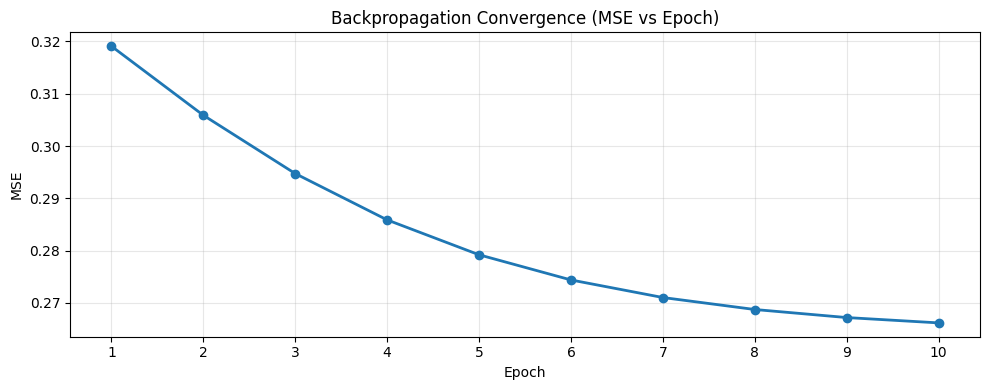

Prediction results table:


,Input,Target,Predicted Probability,Predicted Class
0,"[0.0, 0.0]",0,0.537470,1
1,"[0.0, 1.0]",1,0.539802,1
2,"[1.0, 0.0]",1,0.539351,1
3,"[1.0, 1.0]",0,0.541559,1


In [9]:
# 9) Formatted results tables + plotted convergence (using pandas and matplotlib)

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Re-train once and store epoch-wise details for a proper results table
w_i1_h1 = 0.15
w_i2_h1 = 0.20
w_i1_h2 = 0.25
w_i2_h2 = 0.30
b_h1 = 0.35
b_h2 = 0.35
w_h1_o1 = 0.40
w_h2_o1 = 0.45
b_o1 = 0.60

epoch_rows = []

for epoch in range(1, epochs + 1):
    total_squared_error = 0.0

    for i in range(len(X)):
        x1 = X[i][0]
        x2 = X[i][1]
        target = y[i]

        # Forward pass
        net_h1 = x1 * w_i1_h1 + x2 * w_i2_h1 + b_h1
        out_h1 = 1.0 / (1.0 + (2.718281828 ** (-net_h1)))

        net_h2 = x1 * w_i1_h2 + x2 * w_i2_h2 + b_h2
        out_h2 = 1.0 / (1.0 + (2.718281828 ** (-net_h2)))

        net_o1 = out_h1 * w_h1_o1 + out_h2 * w_h2_o1 + b_o1
        out_o1 = 1.0 / (1.0 + (2.718281828 ** (-net_o1)))

        # Error
        error_o1 = target - out_o1
        total_squared_error = total_squared_error + (error_o1 * error_o1)

        # Backward pass
        delta_o1 = error_o1 * out_o1 * (1.0 - out_o1)
        error_h1 = delta_o1 * w_h1_o1
        error_h2 = delta_o1 * w_h2_o1
        delta_h1 = error_h1 * out_h1 * (1.0 - out_h1)
        delta_h2 = error_h2 * out_h2 * (1.0 - out_h2)

        # Weight updates
        w_h1_o1 = w_h1_o1 + learning_rate * delta_o1 * out_h1
        w_h2_o1 = w_h2_o1 + learning_rate * delta_o1 * out_h2
        b_o1 = b_o1 + learning_rate * delta_o1

        w_i1_h1 = w_i1_h1 + learning_rate * delta_h1 * x1
        w_i2_h1 = w_i2_h1 + learning_rate * delta_h1 * x2
        w_i1_h2 = w_i1_h2 + learning_rate * delta_h2 * x1
        w_i2_h2 = w_i2_h2 + learning_rate * delta_h2 * x2
        b_h1 = b_h1 + learning_rate * delta_h1
        b_h2 = b_h2 + learning_rate * delta_h2

    mse = total_squared_error / len(X)

    epoch_rows.append({
        "Epoch": epoch,
        "MSE": round(mse, 6),
        "w_i1_h1": round(w_i1_h1, 6),
        "w_i2_h1": round(w_i2_h1, 6),
        "w_i1_h2": round(w_i1_h2, 6),
        "w_i2_h2": round(w_i2_h2, 6),
        "w_h1_o1": round(w_h1_o1, 6),
        "w_h2_o1": round(w_h2_o1, 6),
        "b_h1": round(b_h1, 6),
        "b_h2": round(b_h2, 6),
        "b_o1": round(b_o1, 6)
    })

epoch_df = pd.DataFrame(epoch_rows)
print("Epoch-wise training results table:")
display(epoch_df)

# Plot convergence
plt.figure(figsize=(10, 4))
plt.plot(epoch_df["Epoch"], epoch_df["MSE"], marker="o", linewidth=2)
plt.title("Backpropagation Convergence (MSE vs Epoch)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(alpha=0.3)
plt.xticks(epoch_df["Epoch"])
plt.tight_layout()
plt.show()

# Build formatted prediction results table
prediction_rows = []
for i in range(len(X)):
    x1 = X[i][0]
    x2 = X[i][1]

    net_h1 = x1 * w_i1_h1 + x2 * w_i2_h1 + b_h1
    out_h1 = 1.0 / (1.0 + (2.718281828 ** (-net_h1)))

    net_h2 = x1 * w_i1_h2 + x2 * w_i2_h2 + b_h2
    out_h2 = 1.0 / (1.0 + (2.718281828 ** (-net_h2)))

    net_o1 = out_h1 * w_h1_o1 + out_h2 * w_h2_o1 + b_o1
    out_o1 = 1.0 / (1.0 + (2.718281828 ** (-net_o1)))

    predicted_class = 1 if out_o1 >= 0.5 else 0

    prediction_rows.append({
        "Input": str([x1, x2]),
        "Target": int(y[i]),
        "Predicted Probability": round(out_o1, 6),
        "Predicted Class": predicted_class
    })

pred_df = pd.DataFrame(prediction_rows)
print("Prediction results table:")
display(pred_df)